## ライブラリの設定

In [1]:
import pandas as pd
import numpy as np
import math

import japanize_matplotlib
import matplotlib.pyplot as plt

## 7.3容量反応モデル

### 図7.3 の再現

In [2]:
df = pd.DataFrame(
    {
        "ガス濃度": [1.6907, 1.7242, 1.7552, 1.7842, 1.8113, 1.8369, 1.8610, 1.8839],
        "カブト虫の数": [59, 60, 62, 56, 63, 59, 62, 60],
        "死亡数": [6, 13, 18, 28, 52, 53, 61, 60],
    }
)
df

,ガス濃度,カブト虫の数,死亡数
0,1.6907,59,6
1,1.7242,60,13
2,1.7552,62,18
3,1.7842,56,28
4,1.8113,63,52
5,1.8369,59,53
6,1.8610,62,61
7,1.8839,60,60


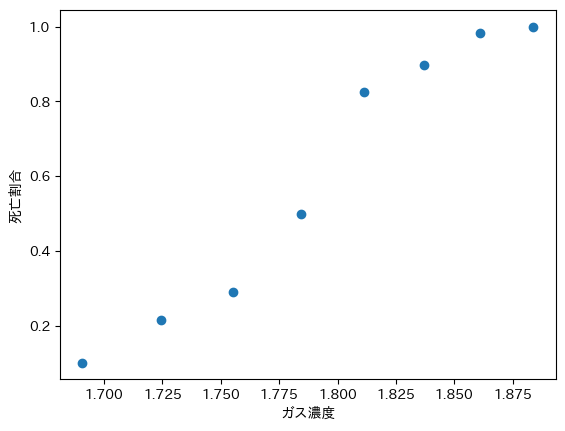

In [3]:
plt.scatter(df["ガス濃度"], df["死亡数"] / df["カブト虫の数"])
plt.xlabel("ガス濃度")
plt.ylabel("死亡割合")
plt.savefig("figure1.png")
plt.show()

### 表7.3の再現

In [4]:
# ロジスティック関数
def logit(beta1, beta2, x):
    return np.exp(beta1 + beta2 * x) / (1 + np.exp(beta1 + beta2 * x))


# 対数尤度関数
def log_likelihood_func(y, beta1, beta2, x, n):
    eta = beta1 + beta2 * x
    temp1 = y * (eta) - n * np.log(1 + np.exp(eta))
    temp2 = np.array(
        [np.log(math.comb(n.values[i], y.values[i])) for i in range(len(y))]
    )
    return (temp1 + temp2).sum()

In [5]:
# 初期値の設定
b1 = 0
b2 = 0

# iterationの回数
n_iters = 6

# データ
x = df["ガス濃度"]
n = df["カブト虫の数"]
y = df["死亡数"]

# Y の分散
Var_Y = y.var()

# mu の計算
mu = y.mean()

# iterごとの係数値
list_initial = [b1, b2, log_likelihood_func(y=y, beta1=b1, beta2=b2, x=x, n=n)]
list_coef = [[], [], []]

# 式(4.22)の逐次法による係数の推定
for iter in range(n_iters):
    # 推定された死亡割合
    pi = logit(b1, b2, x)

    # 情報行列Jの計算
    J = np.array(
        [
            [(n * pi * (1 - pi)).sum(), (n * x * pi * (1 - pi)).sum()],
            [(n * x * pi * (1 - pi)).sum(), (n * (x**2) * pi * (1 - pi)).sum()],
        ]
    )

    # Uの計算
    X = np.stack([np.ones(len(x)), x.values], axis=1)  # デザイン行列
    U_1 = ((y - n * pi) * X[:, 0]).sum()
    U_2 = ((y - n * pi) * X[:, 1]).sum()
    U = np.array([U_1, U_2])

    # 式(4.22)の実装
    b = np.array([b1, b2]) + np.linalg.inv(J) @ U

    # 計数値を更新
    b1 = b[0]
    b2 = b[1]
    log_likeli_hood = log_likelihood_func(y=y, beta1=b1, beta2=b2, x=x, n=n)

    # 1回目
    if iter == 0:
        list_coef[0] = [b1, b2, log_likeli_hood]
        print(f"{iter + 1}回目の beta1 = {b1}, beta2 = {b2}")

    # 2回目
    if iter == 1:
        list_coef[1] = [b1, b2, log_likeli_hood]
        print(f"{iter + 1}回目の beta1 = {b1}, beta2 = {b2}")

    # 6回目
    if iter == 5:
        list_coef[2] = [b1, b2, log_likeli_hood]
        print(f"{iter + 1}回目の beta1 = {b1}, beta2 = {b2}")
df_73 = pd.DataFrame([list_initial] + list_coef).T
df_73.index = ["beta1", "beta2", "対数尤度"]
df_73.columns = ["初期値", "1回目", "2回目", "3回目"]

1回目の beta1 = -37.856376762059085, beta2 = 21.337433744021297
2回目の beta1 = -53.853186974531326, beta2 = 30.383513392397276
6回目の beta1 = -60.71745456163546, beta2 = 34.27032573414701


In [6]:
df_73

,初期値,1回目,2回目,3回目
beta1,0.000000,-37.856377,-53.853187,-60.717455
beta2,0.000000,21.337434,30.383513,34.270326
対数尤度,-165.883525,-32.489488,-19.754081,-18.715135


### 7.4 一般ロジスティック回帰モデル

#### 7.4.1 例

In [7]:
# データ
df = pd.DataFrame(
    {
        "貯蔵条件": ["y1k", "n1k", "y2k", "n2k"],
        "遠心力_40": [55, 102, 55, 76],
        "遠心力_150": [52, 99, 50, 81],
        "遠心力_350": [57, 108, 50, 90],
    }
)
df

,貯蔵条件,遠心力_40,遠心力_150,遠心力_350
0,y1k,55,52,57
1,n1k,102,99,108
2,y2k,55,50,50
3,n2k,76,81,90


##### 図7.4

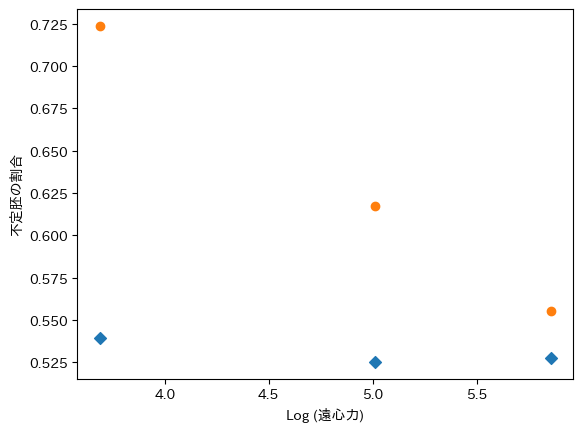

In [8]:
# 対照群と処理群それぞれの不定胚の割合
control = (
    df[df["貯蔵条件"] == "y1k"].iloc[:, 1:].values
    / df[df["貯蔵条件"] == "n1k"].iloc[:, 1:].values
)
treatment = (
    df[df["貯蔵条件"] == "y2k"].iloc[:, 1:].values
    / df[df["貯蔵条件"] == "n2k"].iloc[:, 1:].values
)

# 散布図
x = np.array([np.log(40), np.log(150), np.log(350)])
plt.scatter(x, control[0], marker="D")
plt.scatter(x, treatment[0], marker="o")
plt.xlabel("Log (遠心力)")
plt.ylabel("不定胚の割合")
plt.show()

In [9]:
df

,貯蔵条件,遠心力_40,遠心力_150,遠心力_350
0,y1k,55,52,57
1,n1k,102,99,108
2,y2k,55,50,50
3,n2k,76,81,90


##### 表7.6
モデル1の場合を実装する。

In [10]:
# ロジスティック関数
def logit(beta1, beta2, x):
    return np.exp(beta1 + beta2 * x) / (1 + np.exp(beta1 + beta2 * x))

In [11]:
# データセットの準備
alpha_1 = 0
beta_1 = 0
alpha_2 = 0
beta_2 = 0

# デザイン行列
# ただし、行方向の並び順はalpha_1, beta_1, alpha_2, beta_2 の並び
# x1 = np.log(40)
# x2 = np.log(150)
# x3 = np.log(350)
x1 = 3.689
x2 = 5.011
x3 = 5.858
X = np.array(
    [
        [1, x1, 0, 0],
        [1, x2, 0, 0],
        [1, x3, 0, 0],
        [0, 0, 1, x1],
        [0, 0, 1, x2],
        [0, 0, 1, x3],
    ]
)
x = np.array([x1, x2, x3])

# 対照群のデータ
y1k = df[df["貯蔵条件"] == "y1k"].iloc[:, 1:].values[0]
n1k = df[df["貯蔵条件"] == "n1k"].iloc[:, 1:].values[0]

# 処理群のデータ
y2k = df[df["貯蔵条件"] == "y2k"].iloc[:, 1:].values[0]
n2k = df[df["貯蔵条件"] == "n2k"].iloc[:, 1:].values[0]

# 観測数
n = np.stack([n1k, n2k], axis=0).reshape(-1)

# iterの回数
n_iters = 100

# 最尤推定をNewton-Raphsonで行う
for iter in range(n_iters):
    # 期待値の計算
    pi_1k = logit(beta1=alpha_1, beta2=beta_1, x=x)
    pi_2k = logit(beta1=alpha_2, beta2=beta_2, x=x)
    pi = np.stack([pi_1k, pi_2k], axis=0).reshape(-1)

    # Uの計算
    U1 = (y1k - n1k * pi_1k).sum()
    U2 = ((y1k - n1k * pi_1k) * x).sum()
    U3 = (y2k - n2k * pi_2k).sum()
    U4 = ((y2k - n2k * pi_2k) * x).sum()
    U = np.array([U1, U2, U3, U4])

    # 情報行列Jの計算
    J = []
    for j in range(4):
        list_temp = []
        for k in range(4):
            list_temp.append((n * (X[:, j] * X[:, k]) * (pi * (1 - pi))).sum())
        J.append(list_temp)
    J = np.array(J)

    # パラメータの更新
    b = np.array([alpha_1, beta_1, alpha_2, beta_2]) + np.linalg.inv(J) @ U
    alpha_1 = b[0]
    beta_1 = b[1]
    alpha_2 = b[2]
    beta_2 = b[3]

b = np.round(b, 4)
a1 = b[0]
b1 = b[1]
a2 = b[2]
b2 = b[3]

In [18]:
a2 - a1

1.9772

In [16]:
np.diag(np.sqrt(np.linalg.inv(J)))

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_16636/2559713508.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.diag(np.sqrt(np.linalg.inv(J)))


array([0.62841781, 0.12685057, 0.77540535, 0.15317441])

In [17]:
np.linalg.inv(J)

array([[ 0.39490894, -0.07839257,  0.        ,  0.        ],
       [-0.07839257,  0.01609107, -0.        , -0.        ],
       [ 0.        ,  0.        ,  0.60125346, -0.11701278],
       [-0.        , -0.        , -0.11701278,  0.0234624 ]])